In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

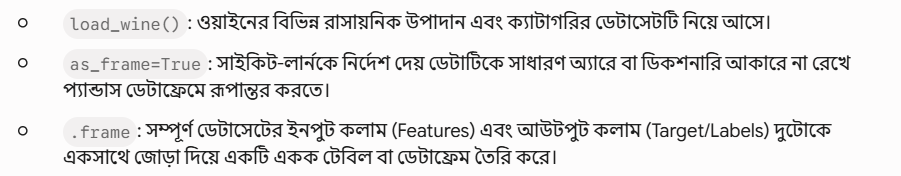

In [ ]:
df = load_wine(as_frame=True).frame

df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
144,12.25,3.88,2.20,18.5,112.0,1.38,0.78,0.29,1.14,8.21,0.65,2.00,855.0,2
167,12.82,3.37,2.30,19.5,88.0,1.48,0.66,0.40,0.97,10.26,0.72,1.75,685.0,2
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0,2
149,13.08,3.90,2.36,21.5,113.0,1.41,1.39,0.34,1.14,9.40,0.57,1.33,550.0,2
48,14.10,2.02,2.40,18.8,103.0,2.75,2.92,0.32,2.38,6.20,1.07,2.75,1060.0,0


In [ ]:
df.shape

(178, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Axes: xlabel='target', ylabel='count'>

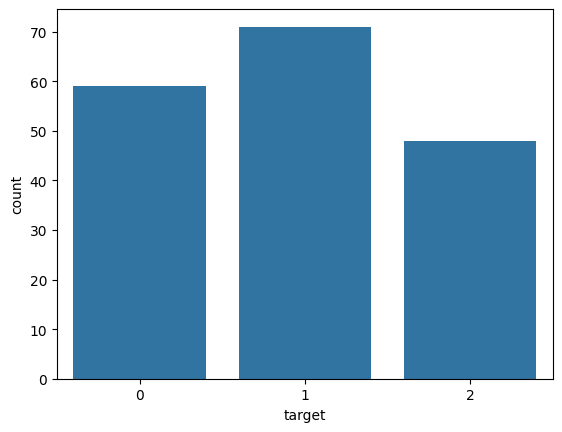

In [ ]:
sns.countplot(data= df , x='target')

In [ ]:
X = df.drop(['target'],axis=1)
y = df['target']

X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520.0
87,11.65,1.67,2.62,26.0,88.0,1.92,1.61,0.40,1.34,2.60,1.36,3.21,562.0
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0
163,12.96,3.45,2.35,18.5,106.0,1.39,0.70,0.40,0.94,5.28,0.68,1.75,675.0


In [ ]:
y_train.nunique()

3

In [ ]:
knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=15,metric='minkowski',p=2))
    ]
)
knn_model.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=15))])

In [ ]:
y_pred = knn_model.predict(X_test)
y_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [ ]:
conf_mat = confusion_matrix(y_test,y_pred)
conf_mat


array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [ ]:
#p2

performance =[]
acc =[]

for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2))
    ]
    )
  knn_model.fit(X_train,y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred,average='weighted')
  recall= recall_score(y_test,y_pred,average='weighted')
  acc.append(accuracy)


  performance.append((k,(accuracy,precision,recall)))




In [ ]:
print(performance)

[(5, (0.9722222222222222, 0.9747474747474748, 0.9722222222222222)), (6, (0.9722222222222222, 0.974074074074074, 0.9722222222222222)), (7, (1.0, 1.0, 1.0)), (8, (1.0, 1.0, 1.0)), (9, (1.0, 1.0, 1.0)), (10, (1.0, 1.0, 1.0)), (11, (1.0, 1.0, 1.0)), (12, (1.0, 1.0, 1.0)), (13, (1.0, 1.0, 1.0)), (14, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (15, (1.0, 1.0, 1.0)), (16, (1.0, 1.0, 1.0)), (17, (1.0, 1.0, 1.0)), (18, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (19, (1.0, 1.0, 1.0)), (20, (1.0, 1.0, 1.0)), (21, (1.0, 1.0, 1.0)), (22, (1.0, 1.0, 1.0)), (23, (1.0, 1.0, 1.0)), (24, (1.0, 1.0, 1.0)), (25, (1.0, 1.0, 1.0)), (26, (1.0, 1.0, 1.0)), (27, (1.0, 1.0, 1.0)), (28, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (29, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222))]


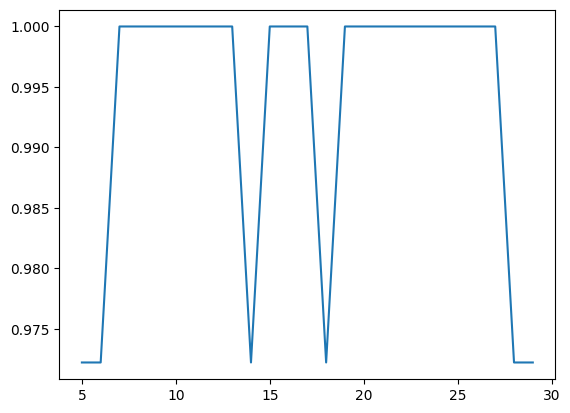

In [ ]:
plt.plot(range(5,30),acc)

In [ ]:
#p1

performance =[]
acc =[]

for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=1))
    ]
    )
  knn_model.fit(X_train,y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred,average='weighted')
  recall= recall_score(y_test,y_pred,average='weighted')
  acc.append(accuracy)


  performance.append((k,(accuracy,precision,recall)))




In [ ]:
print(performance)

[(5, (1.0, 1.0, 1.0)), (6, (1.0, 1.0, 1.0)), (7, (1.0, 1.0, 1.0)), (8, (1.0, 1.0, 1.0)), (9, (1.0, 1.0, 1.0)), (10, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (11, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (12, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (13, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (14, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (15, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (16, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (17, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (18, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (19, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (20, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (21, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (22, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (23, 

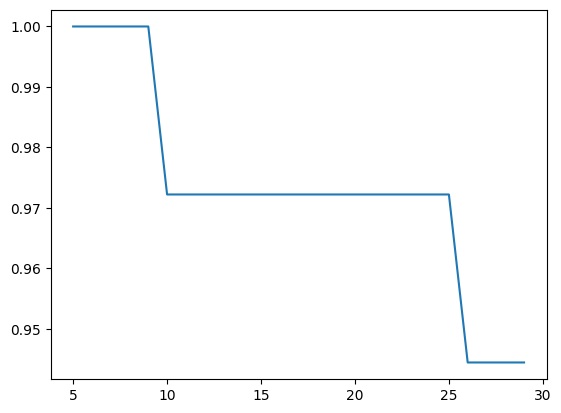

In [ ]:
plt.plot(range(5,30),acc)